# VGG16

In [2]:
import numpy as np
import torch as tr
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from torch.optim import AdamW, SGD
from torch.utils.data.sampler import SubsetRandomSampler
import torch.nn.init as init 
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.utils.class_weight import compute_class_weight

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

import sys
sys.path.insert(1, '/kaggle/input/ferdata-set')
from FERData import FERDataset

from glob import glob

# Device configuration
device = tr.device('cuda' if tr.cuda.is_available() else 'cpu')

In [3]:
kaggle_path = '/kaggle/input/fer2013-custom'

train_transforms = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor()
    ]
)

val_transforms = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ]
)

train_dataset = FERDataset(kaggle_path + '/dataset/train', transform = train_transforms)
val_dataset = FERDataset(kaggle_path + '/dataset/val', transform = val_transforms)
test_dataset =  FERDataset(kaggle_path + '/dataset/test', transform = val_transforms)

In [4]:
batch_size = 16
train_dataLoader = DataLoader(train_dataset, batch_size, shuffle=True)
test_dataLoader = DataLoader(test_dataset, batch_size, shuffle=True)

val_dataLoader = DataLoader(val_dataset, batch_size, shuffle= True)

In [5]:
class VGG16(nn.Module):
    def __init__(self, num_classes=10):
        super(VGG16, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU())
        self.layer2 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2))
        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU())
        self.layer4 = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2))
        self.layer5 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU())
        self.layer6 = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU())
        self.layer7 = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2))
        self.layer8 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU())
        self.layer9 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU())
        self.layer10 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2))
        self.layer11 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU())
        self.layer12 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU())
        self.layer13 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2))
        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(7*7*512, 4096),
            nn.ReLU())
        self.fc1 = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU())
        self.fc2= nn.Sequential(
            nn.Linear(4096, num_classes))
        
    def initialize_weights(self, m):
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
            init.xavier_uniform_(m.weight)
            if m.bias is not None:
                init.constant_(m.bias, 0.0)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.layer5(out)
        out = self.layer6(out)
        out = self.layer7(out)
        out = self.layer8(out)
        out = self.layer9(out)
        out = self.layer10(out)
        out = self.layer11(out)
        out = self.layer12(out)
        out = self.layer13(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        out = self.fc1(out)
        out = self.fc2(out)
        return out

In [6]:
def train(dataLoader, model, optimizer, lossf, lr_scheduler=None):
    model.train()
    losses = []
    total = 0
    correct = 0
    t = 0
    
    for img, label in dataLoader:
        t += 1
        t_imgs = img.to(device, dtype=tr.float)
        t_labels = label.to(device, dtype=tr.int64)
        
        optimizer.zero_grad()
        
        prediction = model(t_imgs)
        loss = lossf(prediction, t_labels)
        losses.append(loss.item())
        
        loss.backward()
        optimizer.step()
        
        _, predicted = tr.max(prediction, 1)
        total += t_labels.size(0)
        correct += (predicted == t_labels).sum().item()
        
        if t % 16 == 0:
            print('|', end='')
    
    train_loss = np.average(losses)
    train_acc = 100.0 * correct / total
    
    print('Train loss is %.3f' % train_loss)
    print('Training acc is %.4f%%' % train_acc)
    
    return


In [7]:
def test(dataLoader, model, lossf):
  model.eval()
  losses, predictions, labels = np.array([]), np.array([]), np.array([])
  result = []

  for img, label in dataLoader:

    t_imgs = img.to(device, dtype=tr.float)
    t_labels = label.to(device, dtype=tr.int64)
    labels = np.append(labels, t_labels.cpu())

    output = model(t_imgs)
    _, prediction = tr.max(output, 1)
    predictions = np.append(predictions, prediction.cpu())

    #create result
    result.append(list(zip(img, label, prediction.cpu())))

    loss = lossf(output, t_labels)
    losses = np.append(losses, loss.item())

  return np.average(losses), predictions, labels, result

In [8]:
def val(dataLoader, model, lossf):
    model.eval()
    losses, predictions, labels = [], [], []
    result = []

    total = 0
    correct = 0

    for img, label in dataLoader:
        t_imgs = img.to(device, dtype=tr.float)
        t_labels = label.to(device, dtype=tr.int64)
        labels.extend(t_labels.cpu().tolist())

        with tr.no_grad():
            output = model(t_imgs)
            _, prediction = tr.max(output, 1)
            predictions.extend(prediction.cpu().tolist())

        # Create result
        result.extend(list(zip(img, label, prediction.cpu().numpy())))

        loss = lossf(output, t_labels)
        losses.append(loss.item())

        total += t_labels.size(0)
        correct += (prediction ==  t_labels).sum().item()

    test_acc = 100.0 * correct / total

    print('One test epoch is over')
    print('Validation acc is %.4f%%' % test_acc)

    return sum(losses)/len(losses), predictions, labels, result


In [9]:
def run(train_dataLoader, val_dataLoader, model, optimizer, lossf, lr_scheduler=None, epochs=50):
    es_counter = 0  # counter early stopping
    es_limit = 20  # epoch limit for early stopping

    best_model = model
    best_epoch = None
    min_avgLosses = float('inf')

    for epoch in range(epochs):
        train(train_dataLoader, model, optimizer, lossf, lr_scheduler)

        val_avgLosses, _, _, _ = val(val_dataLoader, model, lossf)
        print(f'Epoch {epoch} - Validation Loss: {val_avgLosses}')

        if val_avgLosses < min_avgLosses:
            min_avgLosses = val_avgLosses
            best_epoch = epoch
            best_model = model
            
            checkpoint = {'model': VGG16(7),
              'state_dict': best_model.state_dict(),
              'optimizer' : optimizer.state_dict()}

            tr.save(checkpoint, f'checkpoint_{min_avgLosses}.pth')
            print('-------MODELLO SALVATO-------')
            es_counter = 0
        else:
            es_counter += 1

        if es_counter > es_limit - 1:
            print('---- EARLY STOPPING -----')
            break

    print(f'---> Best epoch: {best_epoch}')
    return best_model, min_avgLosses


In [10]:
def load_checkpoint(filepath, phase):
    
    checkpoint = tr.load(filepath)
    model = checkpoint['model']
    model.load_state_dict(checkpoint['state_dict'])
    
    if phase == 'test':
        for parameter in model.parameters():
            parameter.requires_grad = False

        model.eval()
    
    return model

In [11]:
model = VGG16(7).to(device)
model.apply(model.initialize_weights)
# set if you want best last trained model
best_model_flag = True
if best_model_flag:
    models_list = glob('/kaggle/input/model-1/model_*')
    if models_list:
        best_last_model = sorted(models_list)[0]
        model.load_state_dict(tr.load(best_last_model).state_dict())
        print(f'{best_last_model} caricato!')
    else:
        print('Errore nel recupero del modello')
else:
  print('Caricato modello Vanilla!')

optimizer = SGD(model.parameters(),lr = 0.0001, momentum=0.9, weight_decay=5e-4)
lossf = nn.CrossEntropyLoss()

epochs = 50

#lr_scheduler = CosineAnnealingLR(optimizer, T_max=epochs*len(train_dataLoader), eta_min=0)

best_model, min_avgLosses = run(train_dataLoader, val_dataLoader, model, optimizer, lossf,lr_scheduler=None, epochs=epochs)

/kaggle/input/model-1/model_1.0309 caricato!
|||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||Train loss is 0.476
Training acc is 81.9163%
One test epoch is over
Validation acc is 60.8787%
Epoch 0 - Validation Loss: 1.3214168775412771
-------MODELLO SALVATO-------
|||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||Train loss is 0.464
Training acc is 82.6284%
One test epoch is over
Validation acc is 61.7503%
Epoch 1 - Validation Loss: 1.2491543588538965
-------MODELLO SALVATO-------
|||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||Train loss is 0.444
Training acc is 83.4256%
One test epoch is over
Validation acc is 59.5537%
Epoch 2 - Validation Loss: 1.3241245488325755
|||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||Train loss is 0.417
Training acc is 84.6446%
One test epoch is over


In [12]:
#carico il miglior modello dal train nel modello attuale
#model.load_state_dict(best_model.state_dict())

val_avgLosess, val_predictions, val_labels, val_result = val(val_dataLoader, model, lossf)
print(classification_report(val_labels, val_predictions, digits=4))

One test epoch is over
Validation acc is 62.5872%
              precision    recall  f1-score   support

           0     0.6857    0.8328    0.7521       317
           1     0.4610    0.4768    0.4687       409
           2     0.5865    0.5013    0.5405       399
           3     0.5477    0.6593    0.5984       496
           4     0.6013    0.3934    0.4756       483
           5     0.3034    0.6279    0.4091        43
           6     0.8257    0.8211    0.8234       721

    accuracy                         0.6259      2868
   macro avg     0.5730    0.6161    0.5811      2868
weighted avg     0.6312    0.6259    0.6219      2868



In [13]:
#carico il miglior modello dal train nel modello attuale
#model.load_state_dict(best_model)

test_avgLosess, test_predictions, test_labels, test_result = test(test_dataLoader, model, lossf)
print(classification_report(test_labels, test_predictions, digits=4))

              precision    recall  f1-score   support

         0.0     0.6498    0.8327    0.7300       831
         1.0     0.4490    0.4512    0.4501      1024
         2.0     0.5176    0.5073    0.5124       958
         3.0     0.5342    0.6269    0.5769      1233
         4.0     0.5475    0.3376    0.4177      1247
         5.0     0.3262    0.6847    0.4419       111
         6.0     0.8461    0.8089    0.8271      1774

    accuracy                         0.6053      7178
   macro avg     0.5529    0.6070    0.5651      7178
weighted avg     0.6094    0.6053    0.6000      7178



In [14]:
#@title
from sklearn.metrics import confusion_matrix
def get_confusion_matrix(test_labels, test_predictions, labels):

  mat = confusion_matrix(test_labels, test_predictions)
  sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
              xticklabels=labels,
              yticklabels=labels)
  plt.xlabel('true label')
  plt.ylabel('predicted label');
  plt.title(best_last_model if best_last_model else 'First Model')

NameError: name 'plt' is not defined

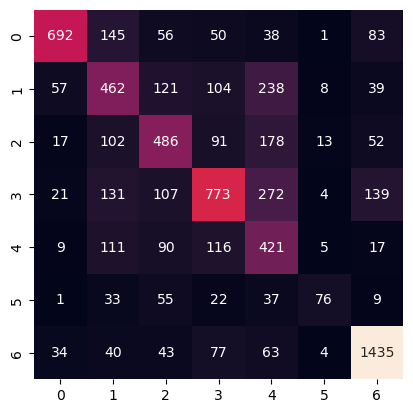

In [15]:
labels = test_dataset.labels.values()
get_confusion_matrix(test_labels, test_predictions, labels)
print(test_dataset.labels)